In [1]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, ReLU, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')

# Принудительно CPU
tf.config.set_visible_devices([], 'GPU')
print("Используемое устройство: CPU")

Используемое устройство: CPU


In [2]:

X_train_df = pd.read_csv('MI-EEG-B9T.csv', header=None)
y_train_df = pd.read_csv('2class_MI_EEG_train_9.csv', header=None)

X_test_df = pd.read_csv('MI-EEG-B9E.csv', header=None)
y_test_df = pd.read_csv('2class_MI_EEG_test_9.csv', header=None)


X_train = X_train_df.values
y_train = y_train_df.values.ravel()

X_test = X_test_df.values
y_test = y_test_df.values.ravel()

# Выравниваем длину (если тест длиннее)
min_test_len = min(len(X_test), len(y_test))
X_test = X_test[:min_test_len]
y_test = y_test[:min_test_len]

# Корректируем метки
if y_train.min() > 0:
    y_train -= y_train.min()
    y_test -= y_test.min()

print(f"Обуч: {X_train.shape} | Тест: {X_test.shape}")
print(f"Метки обуч: {y_train.shape} | Метки тест: {y_test.shape}")


Обуч: (400, 3000) | Тест: (320, 3000)
Метки обуч: (400,) | Метки тест: (320,)


In [3]:
def apply_cwt(data, scales, wavelet_name='morl'):
    n_samples, n_timepoints = data.shape
    n_scales = len(scales)
    cwt_out = np.zeros((n_samples, n_scales, n_timepoints, 1))
    for i in range(n_samples):
        coefs, _ = pywt.cwt(data[i], scales, wavelet_name)
        cwt_out[i,:,:,0] = np.abs(coefs)
    return cwt_out

scales = np.arange(1, 33)
X_train_cwt = apply_cwt(X_train, scales)
X_test_cwt = apply_cwt(X_test, scales)

print(f"Форма CWT обуч: {X_train_cwt.shape}")
print(f"Форма CWT тест: {X_test_cwt.shape}")

Форма CWT обуч: (400, 32, 3000, 1)
Форма CWT тест: (320, 32, 3000, 1)


In [5]:
# МОДЕЛЬ ТОЧНО КАК В ПРИМЕРЕ
model = Sequential([
    Conv2D(16, (3,3), padding='same', input_shape=X_train_cwt.shape[1:]),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2,2)),

    tf.keras.layers.Resizing(8, 8),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/70
13/13 [==============================] - 8s 529ms/step - loss: 1.5714 - accuracy: 0.5300
Epoch 2/70
13/13 [==============================] - 7s 547ms/step - loss: 0.7272 - accuracy: 0.6050
Epoch 3/70
13/13 [==============================] - 7s 528ms/step - loss: 0.6927 - accuracy: 0.5575
Epoch 4/70
13/13 [==============================] - 7s 525ms/step - loss: 0.6703 - accuracy: 0.6050
Epoch 5/70
13/13 [==============================] - 7s 527ms/step - loss: 0.6374 - accuracy: 0.6350
Epoch 6/70
13/13 [==============================] - 7s 523ms/step - loss: 0.5925 - accuracy: 0.6775
Epoch 7/70
13/13 [==============================] - 7s 523ms/step - loss: 0.5793 - accuracy: 0.6725
Epoch 8/70
13/13 [==============================] - 7s 525ms/step - loss: 0.5451 - accuracy: 0.7200
Epoch 9/70
13/13 [==============================] - 7s 522ms/step - loss: 0.5293 - accuracy: 0.7325
Epoch 10/70
13/13 [==============================] - 7s 521ms/step - loss: 0.5610 - accuracy: 0.7025

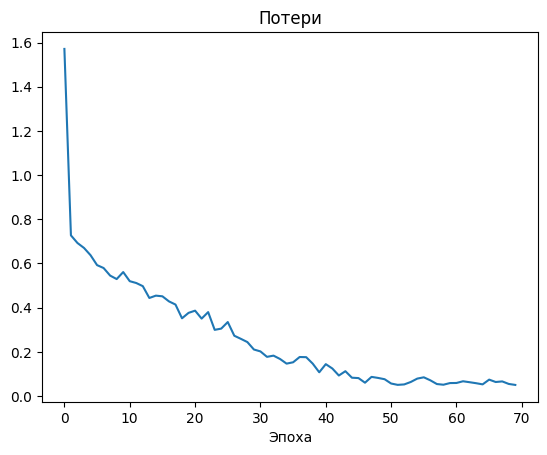

In [6]:
# ОБУЧЕНИЕ
history = model.fit(
    X_train_cwt, y_train,
    batch_size=32,
    epochs=70,
    shuffle=True,
    verbose=1
)

# График потерь
plt.plot(history.history['loss'])
plt.title('Потери')
plt.xlabel('Эпоха')
plt.show()

In [7]:
y_pred = model.predict(X_test_cwt, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# ✅ ГАРАНТИРУЕМ СОВПАДЕНИЕ ДЛИН
y_test = y_test[:len(y_pred_classes)]
acc = accuracy_score(y_test, y_pred_classes)

print(f"Точность на тесте: {acc*100:.2f}%")
print(classification_report(y_test, y_pred_classes, target_names=['Левая рука','Правая рука']))

Точность на тесте: 58.75%
              precision    recall  f1-score   support

  Левая рука       0.62      0.44      0.51       160
 Правая рука       0.57      0.74      0.64       160

    accuracy                           0.59       320
   macro avg       0.60      0.59      0.58       320
weighted avg       0.60      0.59      0.58       320

